<a href="https://colab.research.google.com/github/akshatsharma-x/ML/blob/main/student_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle pandas numpy scikit-learn matplotlib seaborn xgboost

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"vidurgupta7","key":"5574fa5395d8eda34b87749b20ab1f95"}'}

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json|

/bin/bash: -c: line 2: syntax error: unexpected end of file


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score

In [ ]:
!ls

kaggle.json  StudentsPerformance.csv
sample_data  students-performance-in-exams.zip


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   int64
 1   race/ethnicity               1000 non-null   int64
 2   parental level of education  1000 non-null   int64
 3   lunch                        1000 non-null   int64
 4   test preparation course      1000 non-null   int64
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(8)
memory usage: 62.6 KB


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,0.482000,2.174000,2.486000,0.645000,0.642000,66.08900,69.169000,68.054000
std,0.499926,1.157179,1.829522,0.478753,0.479652,15.16308,14.600192,15.195657
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,17.000000,10.000000
25%,0.000000,1.000000,1.000000,0.000000,0.000000,57.00000,59.000000,57.750000
50%,0.000000,2.000000,2.000000,1.000000,1.000000,66.00000,70.000000,69.000000
75%,1.000000,3.000000,4.000000,1.000000,1.000000,77.00000,79.000000,79.000000
max,1.000000,4.000000,5.000000,1.000000,1.000000,100.00000,100.000000,100.000000


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75


REGRESSION

In [ ]:
X = df.drop("math score", axis=1)
y_reg = df["math score"]

CLASSIFICATION

In [ ]:
y_clf = df["math score"].apply(lambda x: 1 if x >= 40 else 0)

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

REGRESSION

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score

models_reg = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "XGBoost": XGBRegressor(),
    "SVR": SVR()
}

results_reg = {}

for name, model in models_reg.items():
    model.fit(X_train, y_reg_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_reg_test, preds)
    results_reg[name] = r2

    print(f"{name} → R2 Score: {r2:.3f}")

Linear Regression → R2 Score: 0.884
Random Forest → R2 Score: 0.846
XGBoost → R2 Score: 0.825
SVR → R2 Score: 0.694


CLASSIFICATION

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

models_clf = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(),
    "KNN": KNeighborsClassifier()
}

results_clf = {}

for name, model in models_clf.items():
    model.fit(X_train, y_clf_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_clf_test, preds)
    results_clf[name] = acc

    print(f"{name} → Accuracy: {acc:.3f}")

Logistic Regression → Accuracy: 0.995
Random Forest → Accuracy: 0.985
SVM → Accuracy: 0.985
XGBoost → Accuracy: 0.975
KNN → Accuracy: 0.970


STUDY RELATED INSIGHT

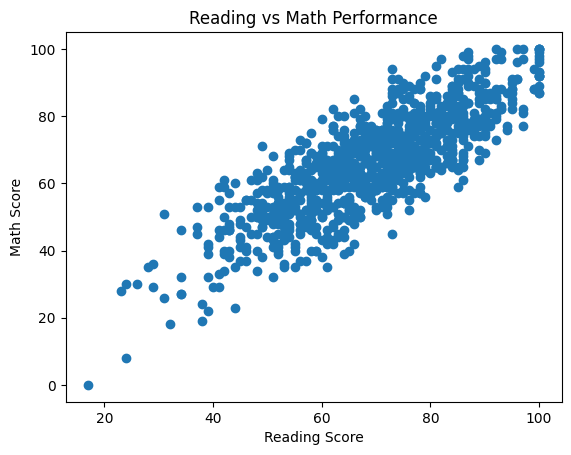

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["reading score"], df["math score"])
plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.title("Reading vs Math Performance")
plt.show()

Heatmap

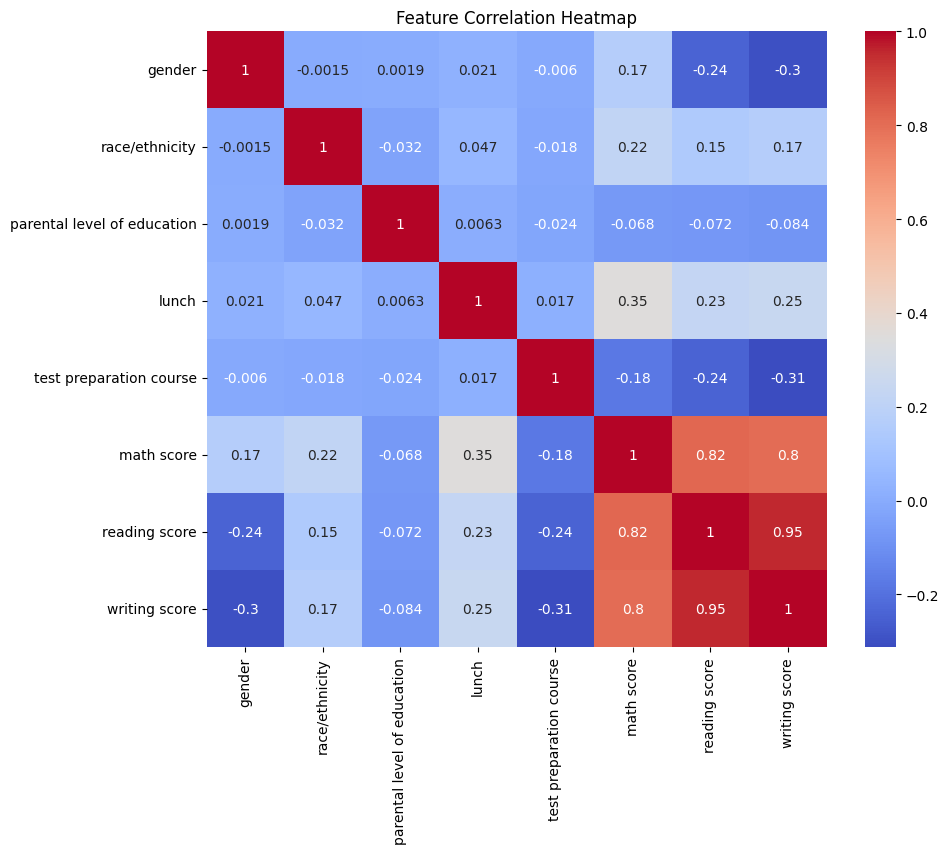

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

Model Comparison

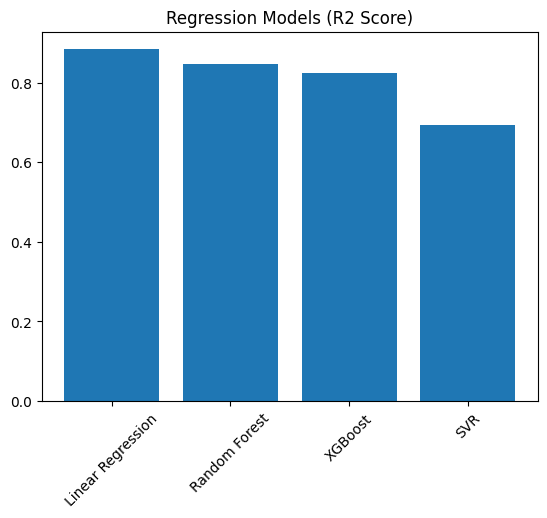

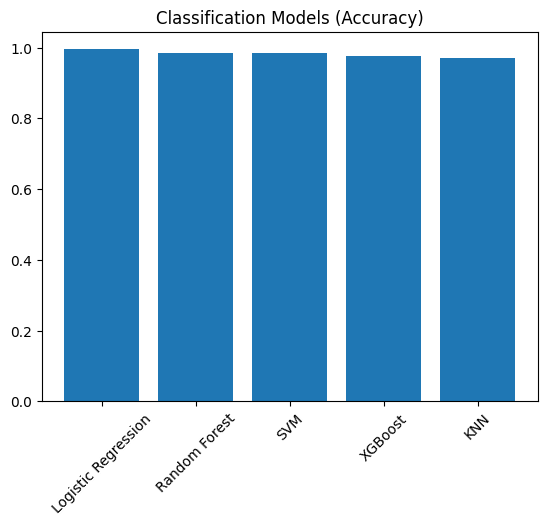

In [ ]:
plt.bar(results_reg.keys(), results_reg.values())
plt.title("Regression Models (R2 Score)")
plt.xticks(rotation=45)
plt.show()

plt.bar(results_clf.keys(), results_clf.values())
plt.title("Classification Models (Accuracy)")
plt.xticks(rotation=45)
plt.show()

FEATURE IMPORTANCE

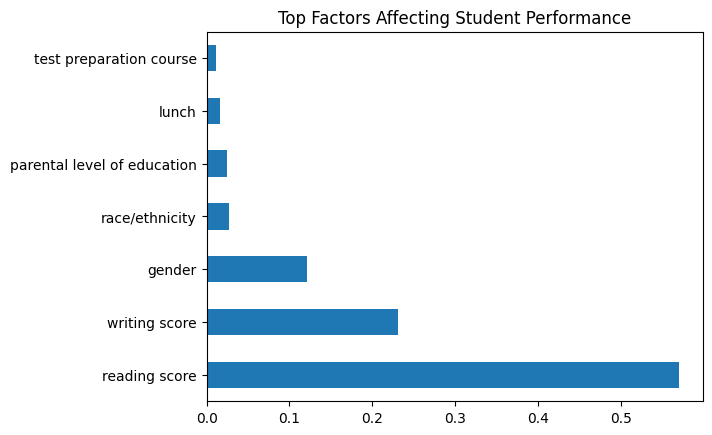

In [ ]:
rf = RandomForestRegressor()
rf.fit(X_train, y_reg_train)

importance = rf.feature_importances_

import pandas as pd
feat_imp = pd.Series(importance, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top Factors Affecting Student Performance")
plt.show()

Impact Analysis

In [ ]:
sample = df.iloc[0].copy()

original = sample.copy()
sample["reading score"] += 20

orig_scaled = scaler.transform([original.drop("math score")])
new_scaled = scaler.transform([sample.drop("math score")])

model = RandomForestRegressor()
model.fit(X_train, y_reg_train)

orig_pred = model.predict(orig_scaled)
new_pred = model.predict(new_scaled)

print(f"Original Predicted Score: {orig_pred[0]:.2f}")
print(f"After Improvement: {new_pred[0]:.2f}")
print(f"Increase: {new_pred[0] - orig_pred[0]:.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Original Predicted Score: 69.76
After Improvement: 74.87
Increase: 5.11


Confusion Matrix

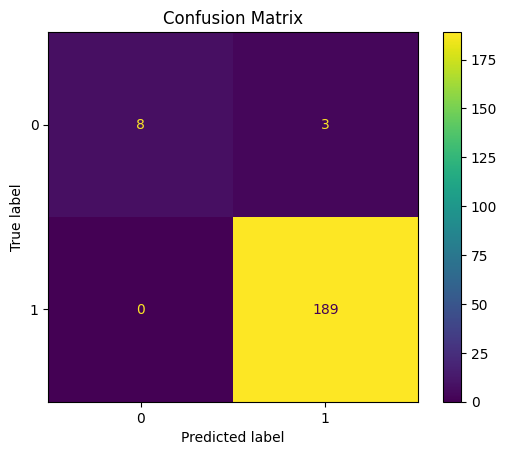

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model = RandomForestClassifier()
model.fit(X_train, y_clf_train)

preds = model.predict(X_test)

cm = confusion_matrix(y_clf_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import joblib

joblib.dump(model, "student_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

GENDER | 0 → Female 1 → Male
LUNCH  | 0 → Standard lunch 1 → Free/Reduced lunch (ews)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_clf_test, preds))

              precision    recall  f1-score   support

           0       1.00      0.73      0.84        11
           1       0.98      1.00      0.99       189

    accuracy                           0.98       200
   macro avg       0.99      0.86      0.92       200
weighted avg       0.99      0.98      0.98       200



**CONCLUSION**

This project analyzed student performance using machine learning techniques.
Both regression and classification models were implemented to predict marks and pass/fail outcomes.
Among all models, Linear Regression performed best for prediction, while Logistic Regression achieved highest accuracy for classification.
Feature importance analysis showed that reading and writing scores strongly influence math performance.
Additionally, increasing reading score significantly improves predicted math marks, indicating strong interdependence between subjects.
This project demonstrates how machine learning can provide actionable insights in education systems.

Saving

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
joblib.dump(model, "/content/drive/MyDrive/student_model.pkl")
joblib.dump(scaler, "/content/drive/MyDrive/scaler.pkl")

['/content/drive/MyDrive/scaler.pkl']